# An IDAES flowsheet under drto

Every other example here declares its model by hand. This one takes a unit
model straight out of [IDAES](https://idaes-pse.readthedocs.io/) and drives it
with drto, to show that the declaration surface attaches to a flowsheet
somebody else built.

The plant is a CSTR running the saponification of ethyl acetate,
`NaOH + EthylAcetate -> SodiumAcetate + Ethanol`, from
`idaes.models.unit_models`. The reaction is exothermic, the manipulated
variables are the jacket duty and the feed flow, as in the hicks example, and
the controlled variable is reactor temperature. The reactor starts hot, at
318 K, and short of conversion, and the controller has to bring it to the
304.04 K steady state the nominal feed alone would settle at.

The whole example is two solves on one declared flowsheet: the model collapsed
to its setpoint, and the infinite-horizon controller.

Residence time is `V/F = 1 s` at the nominal flow, so the horizon is ten
seconds at one-second samples: ten residence times on the horizon, with the
infinite tail carrying the rest.

In [1]:
%matplotlib inline
import pyomo.environ as pyo
import matplotlib.pyplot as plt
import drto
from drto import plot_controls, plot_stage_cost, plot_states
from idaes.core.util.model_statistics import degrees_of_freedom
from models.idaes_cstr import (
    DC_START, F_IN, VOLUME, build, scaled_solve, tag_scaling)


## Declaring the flowsheet

`drto.horizon` captures the set's points as the sample grid, so it has to be
called before discretization. That means the sample times go into
`FlowsheetBlock(time_set=...)` up front rather than being introduced by the
discretizer.

The rest maps one-to-one onto what IDAES already built. The states are the
holdups, whose `DerivativeVar`s are the accumulation terms; the dynamics are
the material and enthalpy balances; the controls are the jacket duty and the
feed flow. The duty is declared on `control_volume.heat` and not on the
unit-level `heat_duty`, which is a Pyomo `Reference` to it: drto classifies
on the referent, and declaring the Reference leaves `heat` looking like an
unexplained algebraic variable. The flow has no flat Var at all, its
variables living inside the property-block members, so it is declared on the
inlet Port's time-indexed Reference, the IDAES inlet idiom. After the
transforms, `drto.info(m).components("control")` hands back the live control
components either way.

The targets are mutable Params, declared empty and filled from the steady
solve below: the declarations come first, and the numbers flow in afterward.

The starting point takes no solve, and it pins the true states only. The
reactor is constant volume with constant molar density, so the water holdup
is algebraic (the package fixes its concentration) and carries no initial
condition: the initial condition covers the four reacting species and the
energy. The reactor starts hot and short of conversion: the setpoint
composition knocked back along the reaction by `DC_START`, at 318 K, and
the controller has to bring both back.

In [2]:
m = build()
drto.info(m)

<drto registry>
states: 5, controls: 32
declarations:
  horizon: fs._time (ContinuousSet, 31 points)
  states: fs.cstr.control_volume.material_holdup_Liq_NaOH (free, mol), fs.cstr.control_volume.material_holdup_Liq_EthylAcetate (free, mol), fs.cstr.control_volume.material_holdup_Liq_SodiumAcetate (free, mol), fs.cstr.control_volume.material_holdup_Liq_Ethanol (free, mol), fs.cstr.control_volume.energy_holdup (free, J)
  dynamics: fs.cstr.control_volume.material_accumulation[t,p,j]  ==  fs.cstr.control_volume.properties_in[t].flow_vol*fs.cstr.control_volume.properties_in[t].conc_mol_comp[j] - fs.cstr.control_volume.properties_out[t].flow_vol*fs.cstr.control_volume.properties_out[t].conc_mol_comp[j] + fs.cstr.control_volume.rate_reaction_generation[t,p,j]  for t in fs.cstr.control_volume.SetProduct_OrderedSet  (mol/s)
  dynamics: fs.cstr.control_volume.energy_accumulation[t,Liq]  ==  fs.props.dens_mol*fs.props.cp_mol*fs.cstr.control_volume.properties_in[t].flow_vol*(fs.cstr.control_volume.properties_in[t].temperature - fs.props.temperature_ref) - fs.props.dens_mol*fs.props.cp_mol*fs.cstr.control_volume.properties_out[t].flow_vol*(fs.cstr.control_volume.properties_out[t].temperature - fs.props.temperature_ref) + fs.cstr.control_volume.heat[t] + (- fs.rxn.dh_rxn[R1]*fs.cstr.control_volume.rate_reaction_extent[t,R1])  for t in fs._time  (W)
  controls: fs.cstr.control_volume.heat (piecewise_constant, free, W), fs.cstr._flow_vol_inlet_ref (piecewise_constant, free, m**3/s)
  tracking stage cost: cost[t]  ==  ((fs.cstr.control_volume.energy_holdup[t,'Liq'] - eng_ss[Liq])/scale_E)**2 + ((fs.cstr.control_volume.heat[t] - duty_ss)/scale_Q)**2 + ((fs.cstr._flow_vol_inlet_ref[t] - flow_ss)/scale_F)**2 + ((fs.cstr.control_volume.material_holdup[t,'Liq','NaOH'] - ss_naoh)/scale_M)**2 + ((fs.cstr.control_volume.material_holdup[t,'Liq','EthylAcetate'] - ss_ea)/scale_M)**2 + ((fs.cstr.control_volume.material_holdup[t,'Liq','SodiumAcetate'] - ss_sa)/scale_M)**2 + ((fs.cstr.control_volume.material_holdup[t,'Liq','Ethanol'] - ss_etoh)/scale_M)**2  for t in sorted(fs._time)[:-1]
  terminal cost: term  ==  ((fs.cstr.control_volume.material_holdup[10.0,Liq,NaOH] - ss_naoh)/scale_M)**2 + ((fs.cstr.control_volume.material_holdup[10.0,Liq,EthylAcetate] - ss_ea)/scale_M)**2 + ((fs.cstr.control_volume.material_holdup[10.0,Liq,SodiumAcetate] - ss_sa)/scale_M)**2 + ((fs.cstr.control_volume.material_holdup[10.0,Liq,Ethanol] - ss_etoh)/scale_M)**2 + ((fs.cstr.control_volume.energy_holdup[10.0,Liq] - eng_ss[Liq])/scale_E)**2
  initial conditions: mat0[j]  ==  fs.cstr.control_volume.material_holdup[0.0,'Liq',j]  for j in OrderedScalarSet  (mol)
  initial conditions: eng0[p]  ==  fs.cstr.control_volume.energy_holdup[0.0,p]  for p in fs.props.phase_list  (J)
  steady-state targets: ss_naoh (of fs.cstr.control_volume.material_holdup_Liq_NaOH, mol), ss_ea (of fs.cstr.control_volume.material_holdup_Liq_EthylAcetate, mol), ss_sa (of fs.cstr.control_volume.material_holdup_Liq_SodiumAcetate, mol), ss_etoh (of fs.cstr.control_volume.material_holdup_Liq_Ethanol, mol), eng_ss (of fs.cstr.control_volume.energy_holdup, J)
  steady-state control targets: duty_ss (of fs.cstr.control_volume.heat, W), flow_ss (of fs.cstr._flow_vol_inlet_ref, m**3/s)
transformations: (none)

## Scaling

The flowsheet runs in raw SI: energy holdups at `1e7` J and duties at `1e6` W
against unit flows, and the collocation equations carry those magnitudes with
order-one coefficients, so double precision floors the residuals near `1e-7`
and the solver stops at an acceptable level instead of full tolerance. The
units on every variable and constraint make the factors mechanical: anything
measured in J scales by `1e-7`, anything in W by `1e-6`; the pin slacks stay
unscaled since they enter the objective linearly with weight `mu`.
`scaled_solve` tags the model, folds the factors into the expressions with
`core.scale_model` so the evaluation itself happens at order one, solves the
scaled clone, and maps the solution back. Every solve below runs through it.

## The setpoint from the declarations

The setpoint is where the nominal feed alone drives the reactor, and the
declared model already contains that equilibrium. `drto.steady_state_simulation`
collapses the flowsheet to a single point and fixes the controls, the duty at
zero and the flow at its nominal value: time leaves the model, the
accumulation terms are pinned, and the IDAES property blocks collapse to
their steady member alongside the flat holdups. The steady
target comes from the same physics the controller uses, with no second
flowsheet to build or keep in sync.

The solution fills the mutable Params: the tracking targets, and the base
composition the initial condition perturbs.

In [3]:
ss = pyo.TransformationFactory("drto.steady_state_simulation").create_using(
    m, controls={m.fs.cstr.control_volume.heat.name: 0.0,
                 m.fs.cstr.inlet.flow_vol.name: F_IN})
assert degrees_of_freedom(ss) == 0
scaled_solve(ss, tee=True)

cvs = ss.fs.cstr.control_volume
print(f"setpoint  T = {pyo.value(cvs.properties_out[0.0].temperature):7.3f} K"
      f"   NaOH = {pyo.value(cvs.properties_out[0.0].conc_mol_comp['NaOH']):6.3f} mol/m3")

for j, ssp in (("NaOH", m.ss_naoh), ("EthylAcetate", m.ss_ea),
               ("SodiumAcetate", m.ss_sa), ("Ethanol", m.ss_etoh)):
    ssp.set_value(pyo.value(cvs.material_holdup["Liq", j]))
# the start: the setpoint composition with conversion knocked back by
# DC_START along the reaction stoichiometry, hot by T_START - T_ss
for j, sgn in (("NaOH", 1), ("EthylAcetate", 1),
               ("SodiumAcetate", -1), ("Ethanol", -1)):
    m.mat0[j] = pyo.value(cvs.material_holdup["Liq", j]) + sgn * DC_START * VOLUME
for k in m.eng_ss:
    m.eng_ss[k] = pyo.value(cvs.energy_holdup[k])
drto.info(ss)

pounce: wrote C:\Users\Devin\AppData\Local\Temp\tmpydcs4pl6.pyomo.sol


********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) â€” drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.9.0, running with linear solver FERAL.

Reading C:\Users\Devin\AppData\Local\Temp\tmpydcs4pl6.pyomo.nl...
Parsed 22 vars, 2

setpoint  T = 304.039 K   NaOH = 24.286 mol/m3


<drto registry>
states: 5, controls: 2
declarations:
  states: fs.cstr.control_volume.material_holdup_Liq_NaOH (free), fs.cstr.control_volume.material_holdup_Liq_EthylAcetate (free), fs.cstr.control_volume.material_holdup_Liq_SodiumAcetate (free), fs.cstr.control_volume.material_holdup_Liq_Ethanol (free), fs.cstr.control_volume.energy_holdup (free)
  dynamics: fs.cstr.control_volume.material_accumulation[o,_r]  ==  fs.cstr.control_volume.properties_in[0.0].flow_vol*fs.cstr.control_volume.properties_in[0.0].conc_mol_comp[_r] - fs.cstr.control_volume.properties_out[0.0].flow_vol*fs.cstr.control_volume.properties_out[0.0].conc_mol_comp[_r] + fs.cstr.control_volume.rate_reaction_generation[o,_r]  for o in fs.props._phase_component_set  (inc)
  dynamics: fs.cstr.control_volume.energy_accumulation[Liq]  ==  fs.props.dens_mol*fs.props.cp_mol*fs.cstr.control_volume.properties_in[0.0].flow_vol*(fs.cstr.control_volume.properties_in[0.0].temperature - fs.props.temperature_ref) - fs.props.dens_mol*fs.props.cp_mol*fs.cstr.control_volume.properties_out[0.0].flow_vol*(fs.cstr.control_volume.properties_out[0.0].temperature - fs.props.temperature_ref) + fs.cstr.control_volume.heat - fs.rxn.dh_rxn[R1]*fs.cstr.control_volume.rate_reaction_extent[R1]  (inc)
  controls: fs.cstr.control_volume.heat (fixed), fs.cstr._flow_vol_inlet_ref (fixed, m**3/s)
  steady-state targets: ss_naoh (of fs.cstr.control_volume.material_holdup_Liq_NaOH, mol), ss_ea (of fs.cstr.control_volume.material_holdup_Liq_EthylAcetate, mol), ss_sa (of fs.cstr.control_volume.material_holdup_Liq_SodiumAcetate, mol), ss_etoh (of fs.cstr.control_volume.material_holdup_Liq_Ethanol, mol), eng_ss (of fs.cstr.control_volume.energy_holdup, J)
  steady-state control targets: duty_ss (of fs.cstr.control_volume.heat, W), flow_ss (of fs.cstr._flow_vol_inlet_ref, m**3/s)
transformations:
  drto.dynamic_to_steady_state: removed=initial condition, tracking terminal cost, collapsed=8 Vars and 8 Constraints to a single point, derivatives=2 fixed at zero, blocks=3 time-indexed Block(s) collapsed to the steady member, 90 member(s) removed, discarded=2 discretization artifacts
  drto.build_objective: objective=zero
  drto.steady_state_simulation: controls=fs.cstr.control_volume.heat=0.0, fs.cstr._flow_vol_inlet_ref=1.0, dropped=tracking stage cost

## The infinite-horizon controller

`drto.infinite_horizon` appends the terminal segment: the IDAES
property blocks replicate onto the tail as algebraic families, and the feed
conditions carry onto it with no declaration involved. The concentrations,
temperature, and pressure are fixed variables, and fixed means fixed: each
one's segment copy is fixed at its horizon-end value. (They are not
disturbances: drto's disturbances are zero-mean noise, which the optimization
mode fixes at zero on the horizon.)

`drto.dynamic_optimization` then frees the controls, applies the declared
profiles and assembles the objective, so the declared model becomes the
solvable controller in two transformation calls.

In [4]:
# initialize from the steady state before any transform: the equilibrium
# solves on a reduced clone and broadcasts flat across the horizon; the
# transforms carry the values onto the moves and the tail on their own
print(drto.initialize_steady_state(
    m, controls={m.fs.cstr.control_volume.heat.name: 0.0,
                 m.fs.cstr.inlet.flow_vol.name: F_IN}))

pyo.TransformationFactory("drto.infinite_horizon").apply_to(
    m,
    nfe=1,                    # finite elements on the terminal segment
    ncp=5,                    # Gauss-Legendre points per element
    beta=1.2,                 # tail overestimation factor, > 1
    gamma="rule",             # the mesh rule, tanh(gamma*dt) = tau_11;
                              # pass a number to override
    profile="collocation",    # segment control profile (pyomo-cvp)
)
pyo.TransformationFactory("drto.dynamic_optimization").apply_to(m)
print("degrees of freedom:", degrees_of_freedom(m))

drto initialize_steady_state (reduce a clone -> solve -> broadcast)
  broadcast: 20 variables across 31 grid points, 186 derivatives zeroed
  pyomo-pounce initialize (fill -> repair -> block-solve)
    decisions held: 2
    values filled : 0
    projection    : optimal
    pyomo-pounce block_initialize
      decisions fixed   : 0
      system square     : True
      blocks solved     : 16 (15 by Newton 1x1, 1 subsystem solves)
      vars initialized  : 23
      left untouched    : 0 underdetermined, 0 overdetermined


degrees of freedom: 41


In [5]:
res = scaled_solve(m, tee=True)
drto.info(m)

********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) — drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.9.0, running with linear solver FERAL.



Number of nonzeros in equality constraint Jacobian...:     3452
Number of nonzeros in inequality constraint Jacobian.:       10
Number of nonzeros in Lagrangian Hessian.............:      475

Total number of variables............................:     1104
                     variables with only lower bounds:      272
                variables with lower and upper bounds:       72
                     variables with only upper bounds:        0
Total number of equality constraints.................:     1063
Total number of inequality constraints...............:        2
        inequality constraints with only lower bounds:        2
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
   0  1.0100000e+02 1.00e+02 1.01e+02   -1.0 0.00e+00      - 0.00e+00 0.00e+00   0
   1  1.0063616e+00 9.68e+01 8.73e+01   -1.0 1.11e+03   -4.0 2.9

   5  3.5477005e+03 8.00e-01 1.41e-02   -1.0 1.59e+07      - 9.90e-01 1.00e+00h  1
   6  3.5491607e+03 3.72e-04 5.27e-06   -1.0 1.26e+09      - 1.00e+00 1.00e+00f  1
   7  3.5366542e+03 1.52e-01 3.64e-02   -2.5 1.21e+08      - 1.00e+00 1.00e+00f  1
   8  3.5379135e+03 2.64e-04 5.27e-05   -2.5 4.15e+09      - 1.00e+00 1.00e+00h  1
   9  3.5376452e+03 1.37e-04 3.18e-05   -3.8 1.31e+01      - 1.00e+00 1.00e+00h  1
iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
  10  3.5376315e+03 4.41e-07 1.02e-07   -5.7 7.24e-01      - 1.00e+00 1.00e+00h  1
  11  3.5376313e+03 1.02e-08 1.52e-11   -8.6 9.02e-03      - 1.00e+00 1.00e+00h  1


  12  3.5376313e+03 8.38e-09 5.07e-13   -9.0 4.57e-08   -5.0 1.00e+00 1.00e+00h  1


Number of Iterations....: 12

                                   (scaled)                 (unscaled)
Objective...............:   3.5376313200619495e+02    3.5376313200619493e+03
Dual infeasibility......:   5.0725454916289331e-13    5.0725454916289331e-12
Constraint violation....:   8.3819031715393066e-09    9.5367431640625000e-07
Variable bound violation:   0.0000000000000000e+00    0.0000000000000000e+00
Complementarity.........:   9.0909109915542662e-10    9.0909109915542658e-09
Overall NLP error.......:   8.3819031715393066e-09    9.5367431640625000e-07


Number of objective function evaluations             = 13
Number of objective gradient evaluations             = 13
Number of equality constraint evaluations            = 13
Number of inequality constraint evaluations          = 13
Number of equality constraint Jacobian evaluations   = 13
Number of inequality constraint Jacobian evaluations = 13
Nu

<drto registry>
states: 5, controls: 2
declarations:
  horizon: fs._time (ContinuousSet, 31 points)
  states: fs.cstr.control_volume.material_holdup_Liq_NaOH (free, mol), fs.cstr.control_volume.material_holdup_Liq_EthylAcetate (free, mol), fs.cstr.control_volume.material_holdup_Liq_SodiumAcetate (free, mol), fs.cstr.control_volume.material_holdup_Liq_Ethanol (free, mol), fs.cstr.control_volume.energy_holdup (free, J)
  dynamics: fs.cstr.control_volume.material_accumulation[t,p,j]  ==  fs.cstr._flow_vol_inlet_ref[0.0]*fs.cstr.control_volume.properties_in[t].conc_mol_comp[j] - fs.cstr.control_volume.properties_out[t].flow_vol*fs.cstr.control_volume.properties_out[t].conc_mol_comp[j] + fs.cstr.control_volume.rate_reaction_generation[t,p,j]  for t in fs.cstr.control_volume.SetProduct_OrderedSet  (mol/s)
  dynamics: fs.cstr.control_volume.energy_accumulation[t,Liq]  ==  fs.props.dens_mol*fs.props.cp_mol*fs.cstr._flow_vol_inlet_ref[0.0]*(fs.cstr.control_volume.properties_in[t].temperature - fs.props.temperature_ref) - fs.props.dens_mol*fs.props.cp_mol*fs.cstr.control_volume.properties_out[t].flow_vol*(fs.cstr.control_volume.properties_out[t].temperature - fs.props.temperature_ref) + fs.cstr.control_volume.heat[0.0] - fs.rxn.dh_rxn[R1]*fs.cstr.control_volume.rate_reaction_extent[t,R1]  for t in fs._time  (W)
  controls: fs.cstr.control_volume.heat (piecewise_constant, free, W), fs.cstr._flow_vol_inlet_ref (piecewise_constant, free, m**3/s)
  tracking stage cost: cost[t]  ==  ((fs.cstr.control_volume.energy_holdup[t,'Liq'] - eng_ss[Liq])/scale_E)**2 + ((fs.cstr.control_volume.heat[t] - duty_ss)/scale_Q)**2 + ((_flow_vol_inlet_ref[t] - flow_ss)/scale_F)**2 + ((fs.cstr.control_volume.material_holdup[t,'Liq','NaOH'] - ss_naoh)/scale_M)**2 + ((fs.cstr.control_volume.material_holdup[t,'Liq','EthylAcetate'] - ss_ea)/scale_M)**2 + ((fs.cstr.control_volume.material_holdup[t,'Liq','SodiumAcetate'] - ss_sa)/scale_M)**2 + ((fs.cstr.control_volume.material_holdup[t,'Liq','Ethanol'] - ss_etoh)/scale_M)**2  for t in sorted(fs._time)[:-1]
  terminal cost: term  ==  ((fs.cstr.control_volume.material_holdup[10.0,Liq,NaOH] - ss_naoh)/scale_M)**2 + ((fs.cstr.control_volume.material_holdup[10.0,Liq,EthylAcetate] - ss_ea)/scale_M)**2 + ((fs.cstr.control_volume.material_holdup[10.0,Liq,SodiumAcetate] - ss_sa)/scale_M)**2 + ((fs.cstr.control_volume.material_holdup[10.0,Liq,Ethanol] - ss_etoh)/scale_M)**2 + ((fs.cstr.control_volume.energy_holdup[10.0,Liq] - eng_ss[Liq])/scale_E)**2
  initial conditions: mat0[j]  ==  fs.cstr.control_volume.material_holdup[0.0,'Liq',j]  for j in OrderedScalarSet  (mol)
  initial conditions: eng0[p]  ==  fs.cstr.control_volume.energy_holdup[0.0,p]  for p in fs.props.phase_list  (J)
  steady-state targets: ss_naoh (of fs.cstr.control_volume.material_holdup_Liq_NaOH, mol), ss_ea (of fs.cstr.control_volume.material_holdup_Liq_EthylAcetate, mol), ss_sa (of fs.cstr.control_volume.material_holdup_Liq_SodiumAcetate, mol), ss_etoh (of fs.cstr.control_volume.material_holdup_Liq_Ethanol, mol), eng_ss (of fs.cstr.control_volume.energy_holdup, J)
  steady-state control targets: duty_ss (of fs.cstr.control_volume.heat, W), flow_ss (of fs.cstr._flow_vol_inlet_ref, m**3/s)
  cost_group: drto_ih, drto_ih
transformations:
  drto.infinite_horizon: segment=1 elements x 5 Legendre points, beta=1.2, gamma=0.04694445, profile=collocation, horizon=kept, infinite tail appended, algebraic=3 components replicated, blocks=3 time-indexed Block(s): 9 components, 3 equation families replicated, partial=2 partially declared container(s) copied per member, terminal_cost=terminal deactivated (the tail owns it), terminal=soft pin z(tau=1)=z_s on 5 states, mu=1000.0
  drto.parameterize: profiles=fs.cstr.control_volume.heat (piecewise_constant), fs.cstr._flow_vol_inlet_ref (piecewise_constant)
  drto.build_objective: objective=sum of 35 weighted cost terms
  drto.dynamic_optimization: horizon=kept, tracking_weight=(one stage cost declared), sensitivity=5 initial-

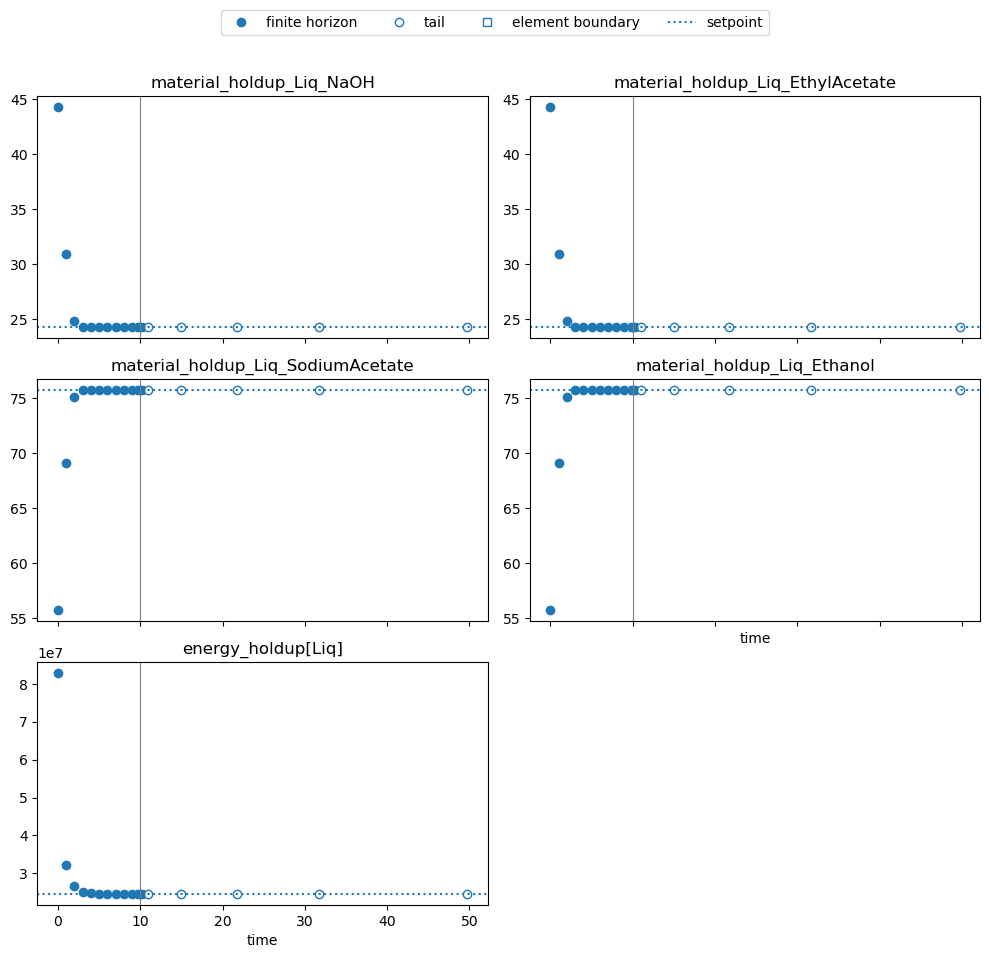

In [6]:
# drto-aware plotting: filled points on the finite horizon, open points on
# the terminal segment mapped back to real time, dotted setpoint lines from
# the declared pairings. With V = 1 m3 the material holdup reads as
# concentration, and the energy holdup is the temperature story in J.
plot_states(m);
plt.show()

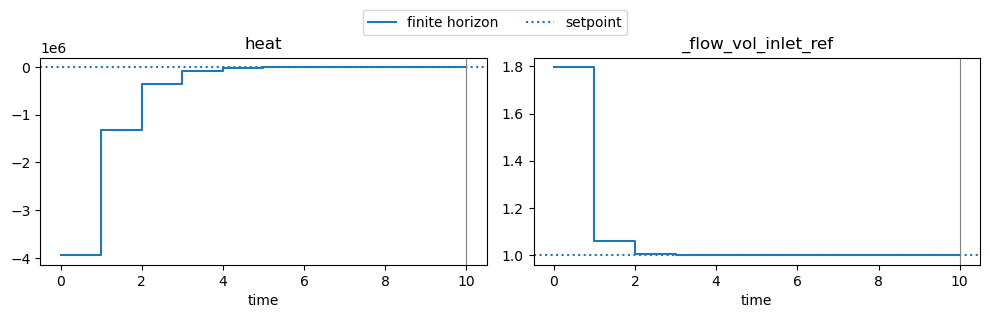

In [7]:
plot_controls(m);
plt.show()

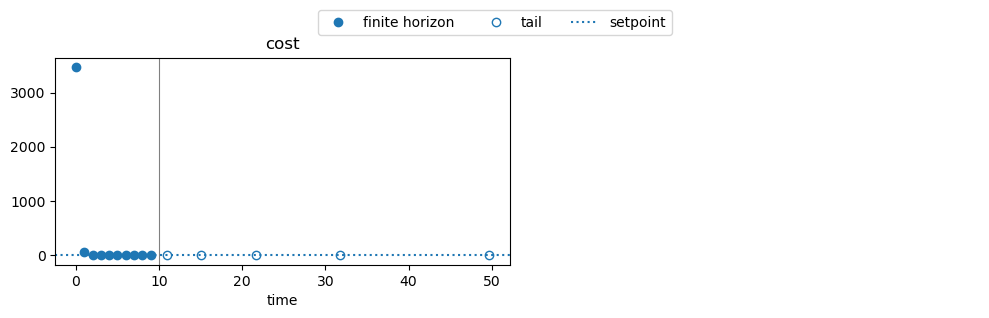

In [8]:
plot_stage_cost(m);
plt.show()